# 04 — Feature Engineering

**Goal:** Create new columns (features) that help Machine Learning models understand time, physics, and historical context. Models don't inherently understand that 11:59 PM is next to 12:00 AM, or what happened yesterday. We have to mathematically teach them.

## 1. Imports & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

CLEANED_PATH = '../data/processed/cleaned.csv'
FEATURED_PATH = '../data/processed/featured.csv'

# Load cleaned data and restore datetime index
df = pd.read_csv(CLEANED_PATH, parse_dates=['datetime'], index_col='datetime')

# Resample to HOURLY frequency to speed up ML training and reduce noise
# For power (kW) we take the mean. For energy (Wh) we take the sum.
df_hourly = df.resample('H').agg({
    'Global_active_power': 'mean',
    'Global_reactive_power': 'mean',
    'Voltage': 'mean',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum'
})
print(f'Resampled to hourly. Shape: {df_hourly.shape}')

Resampled to hourly. Shape: (16941, 6)


## 2. Physics Features (Domain Knowledge)

**What:** Calculating the energy that isn't captured by the three specific sub-meters.
**Why:** It creates a catch-all feature for lights, fridges, and small electronics, giving the model a fuller picture of total house activity.

In [2]:
# Active power is in kW (measured every minute). Convert to Watt-hours (Wh) for the hour.
# Since we resampled to hourly mean, the hourly energy in Wh is roughly: Mean kW * 1000
df_hourly['Total_energy_Wh'] = df_hourly['Global_active_power'] * 1000

# Unmetered = Total - (Kitchen + Laundry + HVAC)
df_hourly['unmetered_energy'] = df_hourly['Total_energy_Wh'] - (df_hourly['Sub_metering_1'] + df_hourly['Sub_metering_2'] + df_hourly['Sub_metering_3'])
df_hourly['unmetered_energy'] = df_hourly['unmetered_energy'].clip(lower=0) # Fix minor negative math artifacts

df_hourly[['Total_energy_Wh', 'unmetered_energy']].head(3)

,Total_energy_Wh,unmetered_energy
datetime,,
2006-12-16 17:00:00,4222.888889,3596.888889
2006-12-16 18:00:00,3632.200000,2217.200000
2006-12-16 19:00:00,3400.233333,2313.233333


## 3. Time-Based Features & Cyclical Encoding

**What:** Extracting Hour, Day, and Month, and turning them into Sine/Cosine waves.
**Why:** If we just use `Hour = 23` and `Hour = 0`, a math model thinks they are 23 units apart. By using sine and cosine, we map them onto a circle, teaching the model that 23 and 0 are right next to each other.

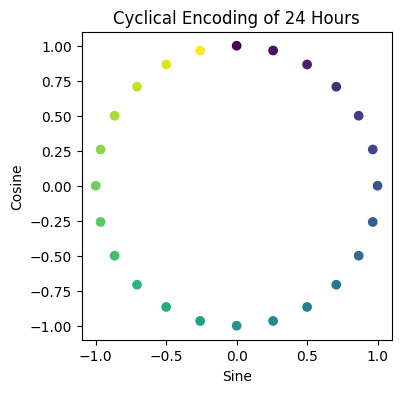

In [3]:
# Extract raw time components
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek
df_hourly['month'] = df_hourly.index.month
df_hourly['is_weekend'] = df_hourly['day_of_week'].isin([5, 6]).astype(int)

# Cyclical Encoding (mapping to a circle)
df_hourly['hour_sin'] = np.sin(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['hour_cos'] = np.cos(2 * np.pi * df_hourly['hour'] / 24)

df_hourly['month_sin'] = np.sin(2 * np.pi * df_hourly['month'] / 12)
df_hourly['month_cos'] = np.cos(2 * np.pi * df_hourly['month'] / 12)

# Let's visualize the circle for Hour
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(df_hourly['hour_sin'][:24], df_hourly['hour_cos'][:24], c=df_hourly['hour'][:24], cmap='viridis')
ax.set_title('Cyclical Encoding of 24 Hours')
ax.set_xlabel('Sine'); ax.set_ylabel('Cosine')
plt.show()

## 4. Lag Features (The Model's "Memory")

**What:** Shifting the target variable backwards in time.
**Why:** Our EDA showed that power usage *exactly 24 hours ago* is highly predictive of power usage *right now*. Lag features let the model look into the past.

In [10]:
# We want the model to predict Global_active_power.
# Let's give it what the power was 1 hour ago, 24 hours ago, and 48 hours ago.
df_hourly['lag_1h'] = df_hourly['Global_active_power'].shift(1)
df_hourly['lag_24h'] = df_hourly['Global_active_power'].shift(24)
df_hourly['lag_48h'] = df_hourly['Global_active_power'].shift(48)

df_hourly[['Global_active_power', 'lag_1h', 'lag_24h' , 'lag_48h']].head(26).tail()

,Global_active_power,lag_1h,lag_24h,lag_48h
datetime,,,,
2006-12-19 14:00:00,0.302133,0.300467,NaN,NaN
2006-12-19 15:00:00,0.421367,0.302133,NaN,NaN
2006-12-19 16:00:00,1.372133,0.421367,NaN,NaN
2006-12-19 17:00:00,2.111500,1.372133,2.154900,NaN
2006-12-19 18:00:00,2.204700,2.111500,2.402533,NaN


## 5. Rolling Statistics (Volatility & Momentum)

**What:** Calculating the moving average over the last 6 and 24 hours.
**Why:** A rolling mean tells the model, "Has it been a generally high-usage day or a low-usage day so far?" It smooths out sudden spikes and captures momentum.

In [5]:
# 6-hour rolling mean (smooths out immediate spikes)
df_hourly['rolling_mean_6h'] = df_hourly['Global_active_power'].rolling(window=6).mean()

# 24-hour rolling mean (captures the daily baseline trend)
df_hourly['rolling_mean_24h'] = df_hourly['Global_active_power'].rolling(window=24).mean()

# Because we used shift() and rolling(), the first 48 rows will have NaNs. We drop them.
df_hourly.dropna(inplace=True)

print(f'Final dataset shape after dropping initial NaNs: {df_hourly.shape}')

Final dataset shape after dropping initial NaNs: (16893, 21)


## 6. Save Engineered Features

In [6]:
df_hourly.to_csv(FEATURED_PATH)
print(f'Saved feature-engineered dataset to {FEATURED_PATH}')
df_hourly.info()

Saved feature-engineered dataset to ../data/processed/featured.csv
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16893 entries, 2006-12-18 17:00:00 to 2008-11-21 13:00:00
Freq: h
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    16893 non-null  float64
 1   Global_reactive_power  16893 non-null  float64
 2   Voltage                16893 non-null  float64
 3   Sub_metering_1         16893 non-null  float64
 4   Sub_metering_2         16893 non-null  float64
 5   Sub_metering_3         16893 non-null  float64
 6   Total_energy_Wh        16893 non-null  float64
 7   unmetered_energy       16893 non-null  float64
 8   hour                   16893 non-null  int32  
 9   day_of_week            16893 non-null  int32  
 10  month                  16893 non-null  int32  
 11  is_weekend             16893 non-null  int64  
 12  hour_sin               16893 non-null  float64
 